[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/Advanced-Time-Series/blob/main/notebooks/EN/chapter1_lecture_notebook.ipynb)

# Advanced Time Series Analysis and Forecasting — Chapter 1: Forecast evaluation, scoring rules and combination

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- Loss functions and the optimal point forecast (mean, median, quantile).
- Calibration (PIT) and proper scores (log score, CRPS): ideal and miscalibrated forecasts; the density forecasts of Diebold, Gunther and Tay (1998) re-run on the S&P 500; optimal linear pools.
- Comparing forecasts: Diebold–Mariano with HAC variance and the HLN correction (size simulation, Romanian inflation), Giacomini–White, Atkeson–Ohanian on US inflation, Clark–West and Hansen's SPA on EUR/RON, the Model Confidence Set on Romanian electricity load.
- Combination: the combination puzzle, combination schemes on the US Survey of Professional Forecasters; real-time GDP data.
- The first code cell installs the `arch` package if it is missing (`pip install arch`).
- The SPF microdata file is about 25 MB; the electricity load comes from the public Energy-Charts API (rate-limited: the downloader waits and retries).

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [1]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/ATS/Chapter_1'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


Save your outputs to: /Users/danpele/Documents/Teaching/ATS - Modelarea avansata a seriilor de timp/repo/notebooks/EN


In [2]:
# The arch package (Hansen's SPA test) is not preinstalled in Google Colab: pip install arch
import importlib.util, subprocess, sys
if importlib.util.find_spec('arch') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'arch'])

In [3]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [4]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import ats_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the ATS repository; EUR/RON is the official BNR reference rate.
- Macroeconomic series: FRED (St. Louis Fed), Eurostat and the classic data sets of statsmodels.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [5]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/Advanced-Time-Series/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the ATS repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years


def read_fred(ids, start=None, end=None):
    """FRED series (St. Louis Fed) from the public fredgraph CSV, e.g. read_fred('UNRATE') or
    read_fred(['GDPC1', 'CPIAUCSL']). Returns a Series (one id) or a DataFrame (several ids)."""
    one = isinstance(ids, str)
    ids = [ids] if one else list(ids)
    out = []
    for sid in ids:
        key = ('fred', sid)
        if key not in _CACHE:
            url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}'
            t = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
            _CACHE[key] = pd.to_numeric(t.iloc[:, 0], errors='coerce').rename(sid)
        out.append(_CACHE[key])
    df = pd.concat(out, axis=1).loc[start:end]
    df.index.name = 'date'
    return df.iloc[:, 0].dropna() if one else df


def _eurostat_period(p):
    p = str(p)
    if '-Q' in p:
        y, q = p.split('-Q')
        return pd.Timestamp(int(y), 3 * int(q) - 2, 1)
    if '-' in p and len(p) == 7:
        return pd.Timestamp(p + '-01')
    if len(p) == 4:
        return pd.Timestamp(int(p), 1, 1)
    return pd.Timestamp(p)


def read_eurostat(dataset, key, start=None):
    """One Eurostat series from the public SDMX 2.1 API (SDMX-CSV), e.g. Romanian quarterly real GDP,
    seasonally and calendar adjusted, chain-linked volumes (2010) in million EUR:
        read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
    `key` is the dot-separated series key of the dataset (dimensions in the order of the dataset)."""
    url = (f'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{dataset}/{key}?format=SDMX-CSV'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('eurostat', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{dataset}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def load_statsmodels(name):
    """Classic data sets shipped with statsmodels (offline): 'sunspots' (yearly, 1700-2008), 'co2' (weekly,
    Mauna Loa, 1958-2001), 'macrodata' (US quarterly macro, 1959-2009), 'nile' (yearly Nile flow, 1871-1970)."""
    import statsmodels.api as sm
    if name == 'sunspots':
        d = sm.datasets.sunspots.load_pandas().data
        s = d.set_index(pd.to_datetime(d['YEAR'].astype(int).astype(str)))['SUNACTIVITY']
        s.index.name = 'date'
        return s.rename('sunspots')
    if name == 'co2':
        return sm.datasets.co2.load_pandas().data['co2'].rename('co2')
    if name == 'macrodata':
        d = sm.datasets.macrodata.load_pandas().data
        d.index = pd.period_range('1959Q1', periods=len(d), freq='Q').to_timestamp()
        d.index.name = 'date'
        return d
    if name == 'nile':
        d = sm.datasets.nile.load_pandas().data
        s = d.set_index(pd.to_datetime(d['year'].astype(int).astype(str)))['volume']
        s.index.name = 'date'
        return s.rename('nile')
    raise KeyError(f'unknown statsmodels data set: {name}')

## Definitions and helpers used in the whole notebook

- Scores and tests: `pinball`, `interval_score`, `crps_normal`, `crps_t`, `hac_var`, `dm_test` (DM with HLN), `gw_test`, `cw_test`, `mz_test`, `encompassing_test`, `berkowitz_test`, `mcs`.
- Data: `spf_sheet`, `us_cpi_quarterly`, `ro_load_hourly`, `realtime_gdp`; models: `garch_fit`, `garch_filter`; combination: `spf_panel`, `combine_spf`.

In [6]:
import io
import urllib.error
from scipy import special
import statsmodels.api as sm
SEED = 2026
HICP_RO = ('prc_hicp_minr', 'M.RCH_A.TOTAL.RO')
RATE_RO = ('irt_st_m', 'M.IRT_M3.RO')
RATE_EA = ('irt_st_m', 'M.IRT_M3.EA')
SPF_URL = 'https://www.philadelphiafed.org/-/media/FRBP/Assets/Surveys-And-Data/survey-of-professional-forecasters/historical-data/SPFmicrodata.xlsx'
RTDSM_URL = 'https://www.philadelphiafed.org/-/media/FRBP/Assets/Surveys-And-Data/real-time-data/data-files/xlsx/routput_first_second_third.xlsx'
LOAD_API = 'https://api.energy-charts.info/public_power?country=ro&start={a}&end={b}'
LOAD_YEARS = (2023, 2024, 2025, 2026)
LOAD_END = '2026-09-30'
DGT_SPLIT = ('2000-01-01', '2012-12-31', '2026-09-18')
INFL_H, INFL_WIN, INFL_P = 12, 120, 3
INFL_EVAL = '2013-01-01'
BNR_TARGET = 2.5
AO_WIN, AO_LAGS, AO_EVAL = 60, 4, '1985-01-01'
FX_START, FX_EVAL = '2005-07-01', '2010-01-01'
LOAD_WIN, LOAD_RES, LOAD_EVAL = 364, 182, '2025-01-01'
TAUS = np.arange(1, 100) / 100
SPF_VAR, SPF_H = 'CPI', 6
SPF_EVAL = (1990, 2025)
SPF_WIN, SPF_MIN = 20, 8
MCS_ALPHA, BOOT_B, BLOCK = 0.1, 2000, 7
_FILES = {}


def get_bytes(url):
    """Download a public file once per session (no key)."""
    import hashlib
    import time
    if url in _FILES:
        return _FILES[url]
    cache = os.environ.get('ATS_CACHE')                 # optional local cache folder (not needed in Colab)
    path = os.path.join(cache, hashlib.md5(url.encode()).hexdigest()) if cache else None
    if path and os.path.exists(path):
        _FILES[url] = open(path, 'rb').read()
        return _FILES[url]
    for attempt in range(6):                            # the Energy-Charts API limits the request rate
        try:
            req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0 (ATS course)'})
            _FILES[url] = urllib.request.urlopen(req, timeout=180).read()
            break
        except urllib.error.HTTPError as e:
            if e.code != 429 or attempt == 5:
                raise
            time.sleep(15 * (attempt + 1))
    if path:
        os.makedirs(cache, exist_ok=True)
        open(path, 'wb').write(_FILES[url])
    return _FILES[url]


def save(name, save_it=True):
    if save_it:
        st.check_no_grey(plt.gcf())
        st.save_fig(name)
    else:
        plt.show()


def pinball(y, q, tau):
    """Quantile (pinball) loss rho_tau(y - q) = (1{y < q} - tau)(q - y)."""
    return ((y < q).astype(float) - tau) * (q - y)


def interval_score(y, lo, hi, alpha):
    """Interval score of a central (1 - alpha) interval (Gneiting and Raftery 2007): width plus 2/alpha times misses."""
    return (hi - lo) + 2 / alpha * (lo - y) * (y < lo) + 2 / alpha * (y - hi) * (y > hi)


def crps_normal(y, mu, sigma):
    """CRPS of N(mu, sigma^2) at y (closed form)."""
    z = (y - mu) / sigma
    return sigma * (z * (2 * stats.norm.cdf(z) - 1) + 2 * stats.norm.pdf(z) - 1 / np.sqrt(np.pi))


def crps_t(y, mu, s, nu):
    """CRPS of a location-scale Student t (location mu, scale s, nu > 1 degrees of freedom) at y (closed form)."""
    z = (y - mu) / s
    term = (2 * np.sqrt(nu) / (nu - 1)) * special.beta(0.5, nu - 0.5) / special.beta(0.5, nu / 2) ** 2
    return s * (z * (2 * stats.t.cdf(z, nu) - 1) + 2 * stats.t.pdf(z, nu) * (nu + z ** 2) / (nu - 1) - term)


def hac_var(x, lags, kernel='bartlett', center=True):
    """Long-run variance of a series: Bartlett (Newey-West) or rectangular (truncated) kernel."""
    x = np.asarray(x, float)
    x = x - x.mean() if center else x
    T = len(x)
    v = x @ x / T
    for k in range(1, lags + 1):
        w = 1 - k / (lags + 1) if kernel == 'bartlett' else 1.0
        v += 2 * w * (x[k:] @ x[:-k]) / T
    return v


def dm_test(d, h=1, kernel='rect', lags=None):
    """Diebold-Mariano test of E[d] = 0 for the loss differential d (model 1 minus model 2) with the HAC variance
    (rectangular kernel with h - 1 lags as in Diebold and Mariano 1995; Bartlett if it is negative) and the
    Harvey-Leybourne-Newbold (1997) small-sample correction with Student t(T - 1) critical values."""
    d = np.asarray(d, float)
    d = d[~np.isnan(d)]
    T = len(d)
    L = h - 1 if lags is None else lags
    v = hac_var(d, L, kernel)
    used = kernel
    if v <= 0:
        v, used = hac_var(d, L, 'bartlett'), 'bartlett'
    dm = d.mean() / np.sqrt(v / T)
    k = np.sqrt((T + 1 - 2 * h + h * (h - 1) / T) / T)
    hln = k * dm
    return {'T': T, 'dbar': float(d.mean()), 'dm': float(dm), 'p_dm': float(2 * stats.norm.sf(abs(dm))),
            'hln': float(hln), 'p_hln': float(2 * stats.t.sf(abs(hln), T - 1)), 'kernel': used}


def gw_test(d, Z, h=1):
    """Giacomini-White (2006) test of conditional equal predictive ability: E[Z_t d_{t+h}] = 0, Wald statistic
    T m' Omega^-1 m ~ chi2(q), with Omega the (uncentred) HAC covariance of Z_t d_{t+h} (h - 1 Bartlett lags)."""
    d = np.asarray(d, float)
    Z = np.column_stack([np.ones(len(d))] + [np.asarray(z, float) for z in Z])
    ok = ~np.isnan(d) & ~np.isnan(Z).any(axis=1)
    X = Z[ok] * d[ok, None]
    T, q = X.shape
    m = X.mean(axis=0)
    S = X.T @ X / T
    for k in range(1, h):
        G = X[k:].T @ X[:-k] / T
        S += (1 - k / h) * (G + G.T)
    stat = float(T * m @ np.linalg.solve(S, m))
    return {'T': int(T), 'q': int(q), 'stat': stat, 'p': float(stats.chi2.sf(stat, q))}


def cw_test(y, f_small, f_big, h=1):
    """Clark-West (2007) test for nested models: adjusted MSPE differential
    f_t = e_small^2 - [e_big^2 - (f_small - f_big)^2]; one-sided t test (H1: the larger model is better)."""
    e1, e2 = y - f_small, y - f_big
    f = e1 ** 2 - (e2 ** 2 - (f_small - f_big) ** 2)
    f = np.asarray(f, float)
    T = len(f)
    v = hac_var(f, max(h - 1, 0), 'bartlett')
    t = f.mean() / np.sqrt(v / T)
    return {'T': T, 'cw': float(t), 'p': float(stats.norm.sf(t))}


def mz_test(y, f, h=1):
    """Mincer-Zarnowitz regression y = a + b f + u with Newey-West standard errors (h - 1 lags, at least 1)
    and the Wald test of (a, b) = (0, 1)."""
    import statsmodels.api as sm
    X = sm.add_constant(np.asarray(f, float))
    m = sm.OLS(np.asarray(y, float), X).fit(cov_type='HAC', cov_kwds={'maxlags': max(h - 1, 1)})
    w = m.wald_test((np.eye(2), np.array([0.0, 1.0])), scalar=True)
    return {'a': float(m.params[0]), 'b': float(m.params[1]), 'se_a': float(m.bse[0]), 'se_b': float(m.bse[1]),
            'wald': float(w.statistic), 'p': float(w.pvalue), 'r2': float(m.rsquared)}


def encompassing_test(y, f1, f2, h=1):
    """Harvey-Leybourne-Newbold (1998) test of H0: forecast 1 encompasses forecast 2, d_t = e1_t (e1_t - e2_t),
    one-sided (H1: E d > 0, forecast 2 adds information), HLN-corrected statistic with t(T - 1)."""
    e1, e2 = y - f1, y - f2
    r = dm_test(e1 * (e1 - e2), h)
    r['p_one'] = float(stats.t.sf(r['hln'], r['T'] - 1))
    return r


def berkowitz_test(u):
    """Berkowitz (2001) LR test: z = Phi^-1(PIT) is i.i.d. N(0, 1) against an AR(1) with free mean and variance."""
    z = stats.norm.ppf(np.clip(np.asarray(u, float), 1e-10, 1 - 1e-10))
    y, x = z[1:], z[:-1]
    X = np.column_stack([np.ones(len(x)), x])
    b = np.linalg.lstsq(X, y, rcond=None)[0]
    res = y - X @ b
    s2 = res @ res / len(y)
    ll1 = np.sum(stats.norm.logpdf(res, scale=np.sqrt(s2)))
    ll0 = np.sum(stats.norm.logpdf(y))
    lr = float(2 * (ll1 - ll0))
    return {'mu': float(b[0] / (1 - b[1])), 'rho': float(b[1]), 'sigma': float(np.sqrt(s2 / (1 - b[1] ** 2))),
            'lr': lr, 'p': float(stats.chi2.sf(lr, 3))}


def mcs(losses, alpha=MCS_ALPHA, B=BOOT_B, block=BLOCK, seed=SEED):
    """Model Confidence Set (Hansen, Lunde and Nason 2011) with the T_max statistic and a moving-block bootstrap:
    eliminate the model with the largest standardised loss differential until the equivalence test is not rejected.
    losses: T x m DataFrame. Returns the MCS p-value of every model and the set at level alpha."""
    L = np.asarray(losses, float)
    L = L[~np.isnan(L).any(axis=1)]
    T, m = L.shape
    rng = np.random.default_rng(seed)
    nb = int(np.ceil(T / block))
    idx = np.concatenate([np.arange(s, s + block) for s in rng.integers(0, T - block + 1, size=(B, nb)).ravel()])
    idx = idx.reshape(B, nb * block)[:, :T]
    Lb = L[idx].mean(axis=1)                          # B x m bootstrap means
    alive = list(range(m))
    pvals = {}
    p_run = 0.0
    while len(alive) > 1:
        Lm = L[:, alive].mean(axis=0)
        dbar = Lm - Lm.mean()                         # d_i. = loss of i minus the average loss of the set
        db = Lb[:, alive] - Lb[:, alive].mean(axis=1, keepdims=True)
        se = np.sqrt(((db - dbar) ** 2).mean(axis=0))
        t = dbar / se
        tb = ((db - dbar) / se).max(axis=1)
        p = float((tb > t.max()).mean())
        p_run = max(p_run, p)
        worst = alive[int(np.argmax(t))]
        pvals[worst] = p_run
        alive.remove(worst)
    pvals[alive[0]] = 1.0
    cols = list(losses.columns) if hasattr(losses, 'columns') else list(range(m))
    out = {cols[i]: pvals[i] for i in range(m)}
    return {'p': out, 'set': [c for c in cols if out[c] >= alpha]}


def spf_sheet(name):
    """One sheet of the SPF microdata file: YEAR, QUARTER, ID, INDUSTRY and the forecasts."""
    return pd.read_excel(io.BytesIO(get_bytes(SPF_URL)), sheet_name=name)


def us_cpi_quarterly():
    """US CPI (FRED CPIAUCSL), quarterly average, and the annualised quarter-on-quarter inflation rate in %."""
    c = read_fred('CPIAUCSL').dropna()
    n = c.resample('QS').count()
    p = c.resample('QS').mean()
    p = p[: n.index[-1] if n.iloc[-1] == 3 else n.index[-2]]           # drop the last quarter if incomplete
    p = p.asfreq('QS')                                                  # (October 2025 was not published: 2 months)
    pi = 100 * ((p / p.shift(1)) ** 4 - 1)
    return p, pi.dropna().rename('pi')


def ro_load_hourly():
    """Romanian hourly electricity load (MW), local time, 2023 to LOAD_END (Energy-Charts, ENTSO-E transparency data):
    the 15-minute values are averaged within each hour; a 24 x days table (DST days: 23 or 25 hours become 24)."""
    parts = []
    for y in LOAD_YEARS:
        b = min(f'{y}-12-31', LOAD_END)
        d = json.loads(get_bytes(LOAD_API.format(a=f'{y}-01-01', b=b)))
        load = [x for x in d['production_types'] if x['name'] == 'Load'][0]['data']
        parts.append(pd.Series(load, index=pd.to_datetime(d['unix_seconds'], unit='s', utc=True), dtype=float))
    s = pd.concat(parts).sort_index()
    s = s[~s.index.duplicated()].tz_convert('Europe/Bucharest')
    df = pd.DataFrame({'y': s.values, 'day': s.index.tz_localize(None).normalize(), 'hour': s.index.hour})
    tab = df.groupby(['day', 'hour'])['y'].mean().unstack('hour')
    tab = tab.interpolate(axis=1, limit_direction='both').interpolate(axis=0, limit_direction='both')
    return tab.loc[:LOAD_END]


def realtime_gdp():
    """US real GDP growth (annualised q/q, %): first, second, third release and the latest vintage (RTDSM)."""
    d = pd.read_excel(io.BytesIO(get_bytes(RTDSM_URL)), sheet_name='DATA', header=None)
    i = d.index[d.iloc[:, 0].astype(str).str.strip() == 'Date'][0]
    t = d.iloc[i + 1:, :5].copy()
    t.columns = ['date', 'first', 'second', 'third', 'latest']
    t = t.dropna(subset=['date'])
    t['date'] = pd.PeriodIndex(t['date'].astype(str).str.replace(':', '-'), freq='Q').to_timestamp()
    return t.set_index('date').apply(pd.to_numeric, errors='coerce')


def garch_filter(p, r, dist, garch=True, ma=True):
    """MA(1)-GARCH(1,1) filter: one-step means m_t and variances s2_t given r_1..r_{t-1}; p = (mu, theta, omega,
    alpha, beta[, nu]). Without GARCH the variance is constant (omega); without MA, theta = 0."""
    mu, th, om, al, be = p[:5]
    th = th if ma else 0.0
    n = len(r)
    m = np.empty(n)
    s2 = np.empty(n)
    e_prev, s2_prev = 0.0, np.var(r)
    for t in range(n):
        m[t] = mu + th * e_prev
        s2[t] = (om + al * e_prev ** 2 + be * s2_prev) if garch else om
        e_prev = r[t] - m[t]
        s2_prev = s2[t]
    return m, s2


def logdens(r, m, s2, dist, nu=None):
    """Log predictive density: Normal, or Student t with unit variance (scale sqrt((nu - 2)/nu))."""
    if dist == 'normal':
        return stats.norm.logpdf(r, m, np.sqrt(s2))
    sc = np.sqrt(s2 * (nu - 2) / nu)
    return stats.t.logpdf((r - m) / sc, nu) - np.log(sc)


def garch_fit(r, dist='t', garch=True, ma=True):
    """Gaussian or Student-t maximum likelihood of the MA(1)-GARCH(1,1) model (or its constant-variance version)."""
    r = np.asarray(r, float)
    v = np.var(r)

    def nll(q):
        p = list(q[:5]) + [None]
        nu = q[5] if dist == 't' else None
        if garch and q[3] + q[4] >= 0.9999:
            return 1e10
        m, s2 = garch_filter(q, r, dist, garch, ma)
        if np.any(s2 <= 0):
            return 1e10
        return -np.sum(logdens(r, m, s2, dist, nu))

    x0 = [r.mean(), 0.0, (0.05 * v if garch else v), (0.08 if garch else 0), (0.9 if garch else 0)] + ([8.0] if dist == 't' else [])
    b = [(None, None), (-0.9, 0.9), (1e-8, None), (0, 1 if garch else 0), (0, 1 if garch else 0)] + ([(2.05, 200)] if dist == 't' else [])
    res = optimize.minimize(nll, x0, method='L-BFGS-B', bounds=b)
    return res.x, -res.fun


def dgt_forecasts():
    """Diebold, Gunther and Tay (1998) re-run on the S&P 500: parameters estimated once on the first sample, one-day
    density forecasts on the second sample: i.i.d. Normal, MA(1)-GARCH(1,1)-Normal, MA(1)-GARCH(1,1)-t."""
    r = log_returns('sp500', DGT_SPLIT[0], DGT_SPLIT[2])
    est = r.loc[:DGT_SPLIT[1]]
    ev_mask = r.index > pd.Timestamp(DGT_SPLIT[1])
    out = {}
    for name, dist, garch in [('iid Normal', 'normal', False), ('GARCH-N', 'normal', True), ('GARCH-t', 't', True)]:
        p, ll = garch_fit(est.values, dist, garch, ma=garch)
        m, s2 = garch_filter(p, r.values, dist, garch, ma=garch)
        nu = p[5] if dist == 't' else None
        y = r.values[ev_mask]
        m, s2 = m[ev_mask], s2[ev_mask]
        if dist == 'normal':
            u = stats.norm.cdf(y, m, np.sqrt(s2))
            crps = crps_normal(y, m, np.sqrt(s2))
        else:
            sc = np.sqrt(s2 * (nu - 2) / nu)
            u = stats.t.cdf((y - m) / sc, nu)
            crps = crps_t(y, m, sc, nu)
        out[name] = {'params': [float(x) for x in p], 'loglik': float(ll), 'pit': u, 'logs': -logdens(y, m, s2, dist, nu),
                     'crps': crps, 'dens': np.exp(logdens(y, m, s2, dist, nu)), 'nu': None if nu is None else float(nu)}
    return r[ev_mask], out


def spf_panel(var=SPF_VAR, h=SPF_H):
    """Individual SPF forecasts of `var`{h} by survey (rows) and forecaster ID (columns), and the realised value of
    the target quarter (survey quarter + h - 2 quarters): annualised q/q CPI inflation (FRED CPIAUCSL)."""
    d = spf_sheet(var)
    col = f'{var}{h}'
    d['survey'] = pd.PeriodIndex.from_fields(year=d['YEAR'], quarter=d['QUARTER'], freq='Q')
    W = d.pivot_table(index='survey', columns='ID', values=col, aggfunc='mean')
    _, pi = us_cpi_quarterly()
    real = pi.copy()
    real.index = pd.PeriodIndex(real.index, freq='Q')
    target = W.index + (h - 2)
    y = pd.Series(real.reindex(target).values, index=W.index, name='y')
    return W, y


def combine_spf(W, y, win=SPF_WIN, minrec=SPF_MIN, lag=None, lam=(0.0, 0.25, 0.5, 0.75, 1.0)):
    """Combination schemes at each survey s (Genre et al. 2013): equal-weight mean, median, 10% trimmed mean,
    inverse-MSE performance weights over the last `win` surveys with a known outcome (at least `minrec` forecasts),
    their shrinkage towards equal weights with factor lambda, and the previous best forecaster."""
    lag = (SPF_H - 1) if lag is None else lag           # outcome of survey s - lag is known at survey s
    E = W.sub(y, axis=0)                                 # forecast errors
    out = []
    surveys = W.index
    for k, s in enumerate(surveys):
        f = W.loc[s].dropna()
        if len(f) < 5 or np.isnan(y.loc[s]):
            continue
        r = {'survey': s, 'y': y.loc[s], 'n': len(f), 'mean': f.mean(), 'median': f.median(),
             'trimmed 10%': stats.trim_mean(f.values, 0.1)}
        past = E.iloc[max(0, k - lag - win + 1):max(0, k - lag + 1)]
        cnt = past[f.index].notna().sum()
        mse = (past[f.index] ** 2).mean()
        ok = cnt[cnt >= minrec].index
        if len(ok) >= 3:
            inv = 1 / mse[ok]
            wp = inv / inv.sum()
            eq = pd.Series(1 / len(ok), index=ok)
            r['mean of eligible'] = f[ok].mean()
            for l in lam:
                r[f'shrink {l:.2f}'] = float(((l * wp + (1 - l) * eq) * f[ok]).sum())
            r['previous best'] = f[mse[ok].idxmin()]
            r['n_ok'] = len(ok)
        out.append(r)
    return pd.DataFrame(out).set_index('survey')

## 1. Loss functions and optimal point forecasts

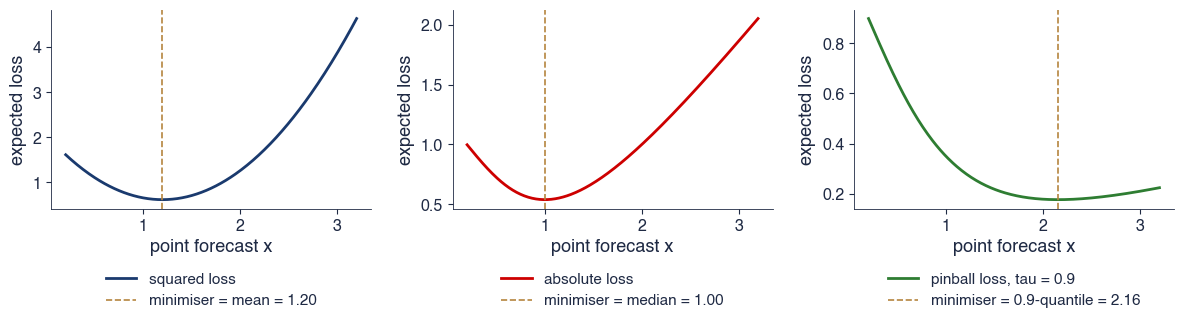

{'sigma': 0.6, 'mean': 1.1972173631218102, 'median': 1.0, 'q90': 2.157458566368321, 'argmin_sq': 1.2, 'argmin_ab': 1.0, 'argmin_pb': 2.16}


In [7]:
def fig_loss_minimizers(save_it=True):
    """Expected squared, absolute and pinball (tau = 0.9) loss of a log-normal Y as functions of the point forecast x."""
    s = 0.6
    rng = np.random.default_rng(SEED)
    y = rng.lognormal(0, s, 200_000)
    xs = np.linspace(0.2, 3.2, 301)
    sq = np.array([np.mean((y - x) ** 2) for x in xs])
    ab = np.array([np.mean(np.abs(y - x)) for x in xs])
    pb = np.array([np.mean(pinball(y, x, 0.9)) for x in xs])
    mean, med, q90 = np.exp(s ** 2 / 2), 1.0, np.exp(s * stats.norm.ppf(0.9))
    fig, axs = plt.subplots(1, 3, figsize=(12, 3.6))
    for ax, v, c, lab, opt, olab in [(axs[0], sq, st.MainBlue, 'squared loss', mean, 'mean'),
                                     (axs[1], ab, st.IDAred, 'absolute loss', med, 'median'),
                                     (axs[2], pb, st.Forest, 'pinball loss, tau = 0.9', q90, '0.9-quantile')]:
        ax.plot(xs, v, color=c, lw=2, label=lab)
        ax.axvline(opt, color=st.Amber, ls='--', lw=1.2, label=f'minimiser = {olab} = {opt:.2f}')
        ax.set_xlabel('point forecast x')
        ax.set_ylabel('expected loss')
        st.legend_outside_bottom(ax, ncol=1, y=-0.25)
    plt.tight_layout()
    save('ats_ch1_loss_minimizers', save_it)
    return {'sigma': s, 'mean': float(mean), 'median': med, 'q90': float(q90),
            'argmin_sq': float(xs[sq.argmin()]), 'argmin_ab': float(xs[ab.argmin()]), 'argmin_pb': float(xs[pb.argmin()])}


print(fig_loss_minimizers(save_it=False))

## 2. Calibration and proper scores

- PIT shapes; expected scores of proper and improper rules.

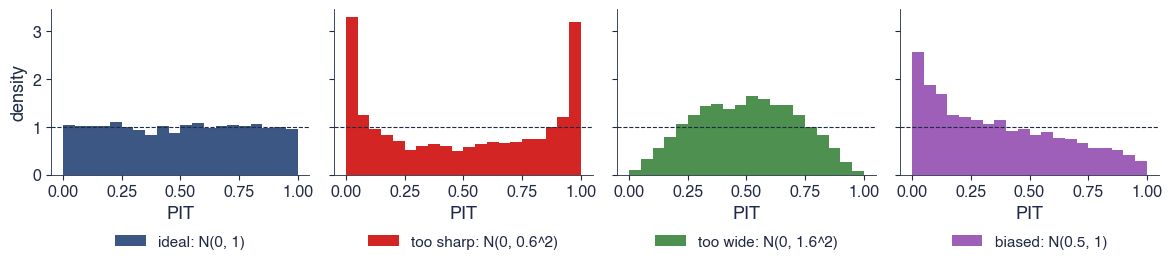

{'ideal': {'share_tails': 0.0992, 'crps': 0.5665230325725565, 'logs': 1.423104241614678}, 'too sharp': {'share_tails': 0.3244, 'crps': 0.5953132059305963, 'logs': 1.8085732105775856}, 'too wide': {'share_tails': 0.0096, 'crps': 0.6044411009006231, 'logs': 1.5858818922980664}, 'biased': {'share_tails': 0.1418, 'crps': 0.6371211499508668, 'logs': 1.5517930967935258}}


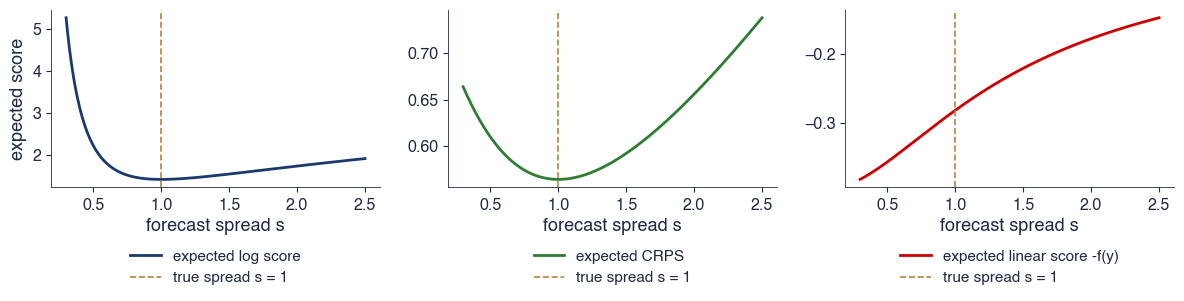

{'argmin_logs': 1.0, 'argmin_crps': 1.0, 'argmin_lin': 0.3}


In [8]:
def fig_pit_shapes(save_it=True, n=5000):
    """PIT histograms of four Normal forecasts of Y ~ N(0, 1): ideal, too sharp, too wide, biased."""
    rng = np.random.default_rng(SEED)
    y = rng.standard_normal(n)
    cases = [('ideal: N(0, 1)', 0, 1, st.MainBlue), ('too sharp: N(0, 0.6^2)', 0, 0.6, st.IDAred),
             ('too wide: N(0, 1.6^2)', 0, 1.6, st.Forest), ('biased: N(0.5, 1)', 0.5, 1, st.Purple)]
    fig, axs = plt.subplots(1, 4, figsize=(12, 3.0), sharey=True)
    out = {}
    for ax, (lab, m, s, c) in zip(axs, cases):
        u = stats.norm.cdf(y, m, s)
        ax.hist(u, bins=20, range=(0, 1), density=True, color=c, alpha=0.85, label=lab)
        ax.axhline(1, color=st.DarkText, lw=0.8, ls='--')
        ax.set_xlabel('PIT')
        st.legend_outside_bottom(ax, ncol=1, y=-0.28)
        out[lab.split(':')[0]] = {'share_tails': float(np.mean((u < 0.05) | (u > 0.95))),
                                  'crps': float(np.mean(crps_normal(y, m, s))),
                                  'logs': float(-np.mean(stats.norm.logpdf(y, m, s)))}
    axs[0].set_ylabel('density')
    plt.tight_layout()
    save('ats_ch1_pit_shapes', save_it)
    return out


def fig_proper_scores(save_it=True):
    """Expected scores of N(0, s^2) forecasts when Y ~ N(0, 1), as functions of s: log score and CRPS are minimised
    at s = 1 (proper); the linear score -f(y) rewards s -> 0 (improper)."""
    s = np.linspace(0.3, 2.5, 221)
    logs = 0.5 * np.log(2 * np.pi * s ** 2) + 1 / (2 * s ** 2)          # E[-log f(Y)]
    crps = np.sqrt(1 + s ** 2) * np.sqrt(2 / np.pi) - s / np.sqrt(np.pi)  # E CRPS(N(0, s^2), Y), Y ~ N(0, 1)
    lin = -1 / np.sqrt(2 * np.pi * (1 + s ** 2))                          # E[-f(Y)]
    fig, axs = plt.subplots(1, 3, figsize=(12, 3.4))
    for ax, v, c, lab in [(axs[0], logs, st.MainBlue, 'expected log score'), (axs[1], crps, st.Forest, 'expected CRPS'),
                          (axs[2], lin, st.IDAred, 'expected linear score -f(y)')]:
        ax.plot(s, v, color=c, lw=2, label=lab)
        ax.axvline(1, color=st.Amber, ls='--', lw=1.2, label='true spread s = 1')
        ax.set_xlabel('forecast spread s')
        st.legend_outside_bottom(ax, ncol=1, y=-0.27)
    axs[0].set_ylabel('expected score')
    plt.tight_layout()
    save('ats_ch1_proper_scores', save_it)
    return {'argmin_logs': float(s[logs.argmin()]), 'argmin_crps': float(s[crps.argmin()]), 'argmin_lin': float(s[lin.argmin()])}


print(fig_pit_shapes(save_it=False))
print(fig_proper_scores(save_it=False))

## 3. Density forecasts of the S&P 500 (Diebold, Gunther and Tay 1998) and optimal pools

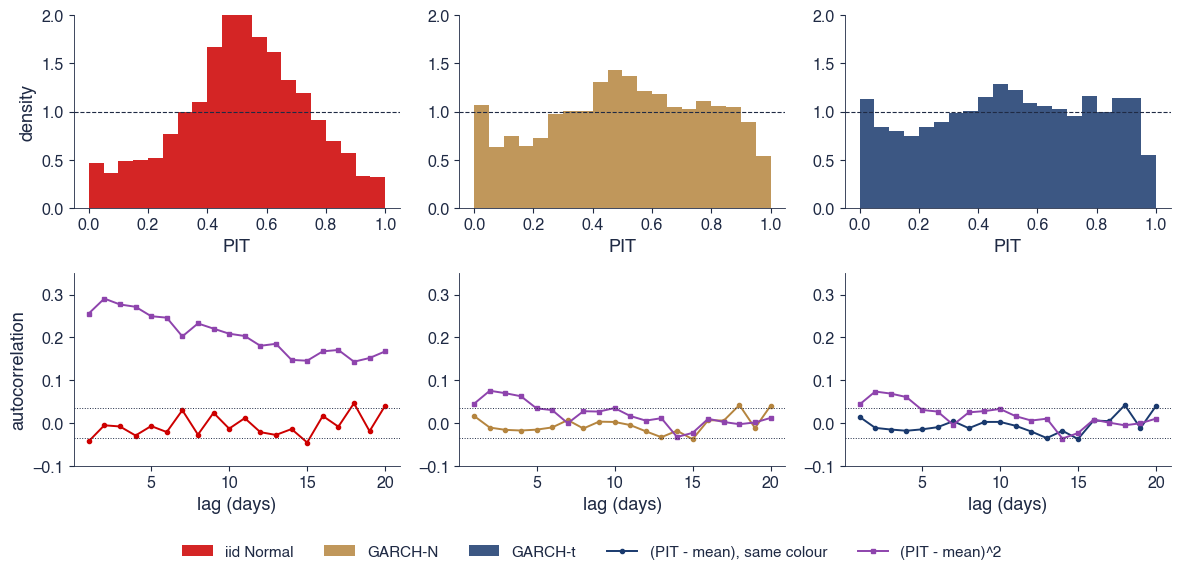

iid Normal {'berk_lr': 428.811, 'berk_p': 0.0, 'berk_rho': -0.108, 'berk_sigma': 0.774, 'tails': 0.039, 'lb2_p': 0.0, 'logs': 1.531, 'crps': 0.564, 'nu': None}
GARCH-N {'berk_lr': 9.291, 'berk_p': 0.026, 'berk_rho': 0.027, 'berk_sigma': 0.969, 'tails': 0.08, 'lb2_p': 0.0, 'logs': 1.265, 'crps': 0.509, 'nu': None}
GARCH-t {'berk_lr': 9.969, 'berk_p': 0.019, 'berk_rho': 0.02, 'berk_sigma': 0.965, 'tails': 0.084, 'lb2_p': 0.0, 'logs': 1.233, 'crps': 0.507, 'nu': 7.997}


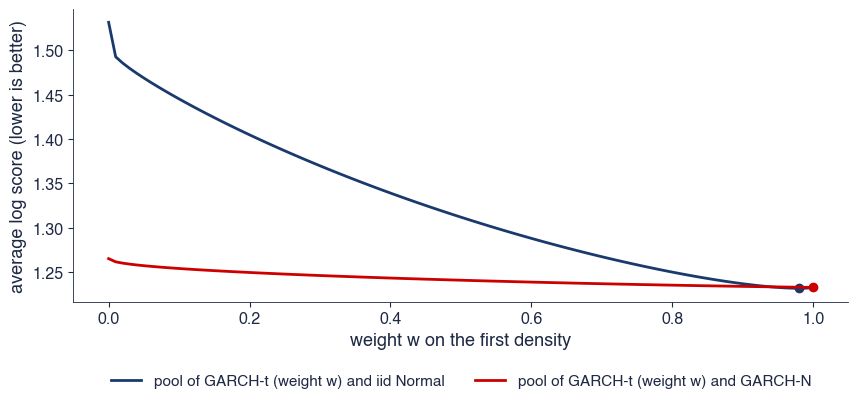

{'GARCH-t|iid Normal': {'w_opt': 0.98, 'ls_opt': 1.2318228978645434, 'ls_a': 1.232830778985808, 'ls_b': 1.5312981971844777}, 'GARCH-t|GARCH-N': {'w_opt': 1.0, 'ls_opt': 1.232830778985808, 'ls_a': 1.232830778985808, 'ls_b': 1.265214896299016}}


In [9]:
def fig_dgt(save_it=True):
    """PIT histograms and correlograms of the centred PIT and its square for the three S&P 500 density forecasts."""
    y, F = dgt_forecasts()
    names = list(F)
    cols = [st.IDAred, st.Amber, st.MainBlue]
    fig, axs = plt.subplots(2, 3, figsize=(12, 5.4))
    res = {'n_eval': int(len(y)), 'first': str(y.index[0].date()), 'last': str(y.index[-1].date())}
    for j, (nm, c) in enumerate(zip(names, cols)):
        u = F[nm]['pit']
        axs[0, j].hist(u, bins=20, range=(0, 1), density=True, color=c, alpha=0.85, label=nm)
        axs[0, j].axhline(1, color=st.DarkText, lw=0.8, ls='--')
        axs[0, j].set_xlabel('PIT')
        axs[0, j].set_ylim(0, 2.0)
        for k, (pw, mk) in enumerate([(1, 'o'), (2, 's')]):
            x = (u - u.mean()) ** pw
            x = x - x.mean()
            ac = [np.corrcoef(x[l:], x[:-l])[0, 1] for l in range(1, 21)]
            axs[1, j].plot(range(1, 21), ac, mk + '-', ms=3, color=c if pw == 1 else st.Purple,
                           label=('(PIT - mean)' if pw == 1 else '(PIT - mean)^2'))
        band = 2 / np.sqrt(len(u))
        axs[1, j].axhline(band, color=st.DarkText, lw=0.7, ls=':')
        axs[1, j].axhline(-band, color=st.DarkText, lw=0.7, ls=':')
        axs[1, j].set_xlabel('lag (days)')
        axs[1, j].set_ylim(-0.1, 0.35)
        bt = berkowitz_test(u)
        lb = stats.chi2.sf(len(u) * (len(u) + 2) * sum(
            np.corrcoef(((u - u.mean()) ** 2)[l:], ((u - u.mean()) ** 2)[:-l])[0, 1] ** 2 / (len(u) - l) for l in range(1, 21)), 20)
        res[nm] = {'berk_lr': bt['lr'], 'berk_p': bt['p'], 'berk_rho': bt['rho'], 'berk_sigma': bt['sigma'],
                   'tails': float(np.mean((u < 0.05) | (u > 0.95))), 'lb2_p': float(lb),
                   'logs': float(np.mean(F[nm]['logs'])), 'crps': float(np.mean(F[nm]['crps'])),
                   'nu': F[nm]['nu'], 'params': F[nm]['params']}
    axs[0, 0].set_ylabel('density')
    axs[1, 0].set_ylabel('autocorrelation')
    h1, l1 = axs[0, 0].get_legend_handles_labels()
    hs = [axs[0, j].get_legend_handles_labels()[0][0] for j in range(3)] + axs[1, 2].get_legend_handles_labels()[0]
    ls = names + ['(PIT - mean), same colour', '(PIT - mean)^2']
    fig.legend(hs, ls, loc='upper center', bbox_to_anchor=(0.5, 0.0), ncol=5, frameon=False)
    plt.tight_layout()
    save('ats_ch1_dgt', save_it)
    # Amisano-Giacomini: DM on log scores and on CRPS
    for a, b in [('GARCH-t', 'GARCH-N'), ('GARCH-N', 'iid Normal'), ('GARCH-t', 'iid Normal')]:
        res[f'ls_{a}_{b}'] = dm_test(F[a]['logs'] - F[b]['logs'], 1)
        res[f'crps_{a}_{b}'] = dm_test(F[a]['crps'] - F[b]['crps'], 1)
    # left-tail weighted log score (censored to the 5% left tail of the iid Normal): share of the difference
    return res


def fig_pool(save_it=True):
    """Optimal linear pools (Geweke and Amisano 2011): average log score of w p_1 + (1 - w) p_2 on the evaluation sample."""
    y, F = dgt_forecasts()
    w = np.linspace(0, 1, 101)
    pairs = [('GARCH-t', 'iid Normal', st.MainBlue), ('GARCH-t', 'GARCH-N', st.IDAred)]
    fig, ax = plt.subplots(figsize=(10, 3.8))
    out = {}
    for a, b, c in pairs:
        ls = np.array([-np.mean(np.log(wi * F[a]['dens'] + (1 - wi) * F[b]['dens'])) for wi in w])
        ax.plot(w, ls, color=c, lw=2, label=f'pool of {a} (weight w) and {b}')
        k = int(ls.argmin())
        ax.plot(w[k], ls[k], 'o', color=c, ms=6)
        out[f'{a}|{b}'] = {'w_opt': float(w[k]), 'ls_opt': float(ls[k]), 'ls_a': float(ls[-1]), 'ls_b': float(ls[0])}
    ax.set_xlabel('weight w on the first density')
    ax.set_ylabel('average log score (lower is better)')
    st.legend_outside_bottom(ax, ncol=2, y=-0.2)
    save('ats_ch1_pool', save_it)
    return out


res = fig_dgt(save_it=False)
for k in ('iid Normal', 'GARCH-N', 'GARCH-t'):
    print(k, {m: (round(v, 3) if isinstance(v, float) else v) for m, v in res[k].items() if m != 'params'})
print(fig_pool(save_it=False))

## 4. Diebold–Mariano: size in small samples and Romanian inflation

- The size simulation uses 1000 replications here (4000 on the slides).

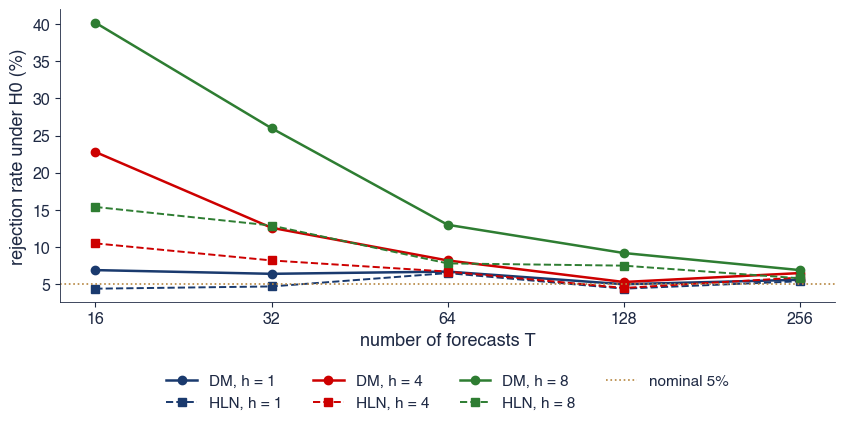

{'1_16': {'dm': 0.069, 'hln': 0.044}, '1_32': {'dm': 0.064, 'hln': 0.047}, '1_64': {'dm': 0.067, 'hln': 0.065}, '1_128': {'dm': 0.05, 'hln': 0.044}, '1_256': {'dm': 0.056, 'hln': 0.054}, '4_16': {'dm': 0.228, 'hln': 0.105}, '4_32': {'dm': 0.126, 'hln': 0.082}, '4_64': {'dm': 0.082, 'hln': 0.067}, '4_128': {'dm': 0.053, 'hln': 0.045}, '4_256': {'dm': 0.065, 'hln': 0.059}, '8_16': {'dm': 0.402, 'hln': 0.154}, '8_32': {'dm': 0.26, 'hln': 0.129}, '8_64': {'dm': 0.13, 'hln': 0.078}, '8_128': {'dm': 0.092, 'hln': 0.075}, '8_256': {'dm': 0.069, 'hln': 0.058}, 'reps': 1000}


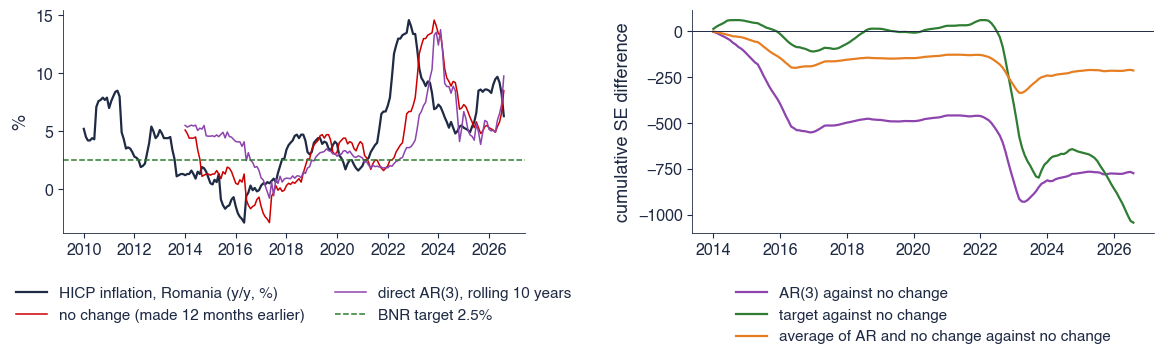

{'rmse_rw': 3.5732375118076707, 'rmse_ar': 4.226161249108904, 'rmse_target_fc': 4.430924520375309, 'rmse_comb': 3.7646738678306857, 'dm_ar': {'T': 152, 'dbar': 5.09241258768026, 'dm': 1.4301116652488834, 'p_dm': 0.15268497268951312, 'hln': 1.3219040567243456, 'p_hln': 0.1881991916282206, 'kernel': 'rect'}, 'gw': {'T': 140, 'q': 3, 'stat': 3.190263078493788, 'p': 0.36321030542879634}}


In [10]:
def fig_dm_size(save_it=True, reps=4000):
    """Monte Carlo size of the DM test (Normal critical values) and of the HLN-corrected test (t(T - 1)) at 5%:
    two independent MA(h - 1) forecast-error series with equal variance, squared-error loss."""
    rng = np.random.default_rng(SEED)
    Ts = [16, 32, 64, 128, 256]
    hs = [1, 4, 8]
    res = {}
    for h in hs:
        for T in Ts:
            rej_dm = rej_hln = 0
            for _ in range(reps):
                u = rng.standard_normal((2, T + h - 1))
                e = np.array([np.convolve(u[i], np.ones(h), 'valid') / np.sqrt(h) for i in range(2)])
                r = dm_test(e[0] ** 2 - e[1] ** 2, h)
                rej_dm += r['p_dm'] < 0.05
                rej_hln += r['p_hln'] < 0.05
            res[f'{h}_{T}'] = {'dm': rej_dm / reps, 'hln': rej_hln / reps}
    fig, ax = plt.subplots(figsize=(10, 3.8))
    cols = {1: st.MainBlue, 4: st.IDAred, 8: st.Forest}
    for h in hs:
        ax.plot(Ts, [100 * res[f'{h}_{T}']['dm'] for T in Ts], 'o-', color=cols[h], lw=1.8, label=f'DM, h = {h}')
        ax.plot(Ts, [100 * res[f'{h}_{T}']['hln'] for T in Ts], 's--', color=cols[h], lw=1.4, label=f'HLN, h = {h}')
    ax.axhline(5, color=st.Amber, lw=1.2, ls=':', label='nominal 5%')
    ax.set_xscale('log', base=2)
    ax.set_xticks(Ts)
    ax.set_xticklabels([str(T) for T in Ts])
    ax.set_xlabel('number of forecasts T')
    ax.set_ylabel('rejection rate under H0 (%)')
    st.legend_outside_bottom(ax, ncol=4, y=-0.2)
    save('ats_ch1_dm_size', save_it)
    res['reps'] = reps
    return res


def ro_inflation_forecasts(h=INFL_H, win=INFL_WIN, p=INFL_P, first=INFL_EVAL):
    """Forecasts of Romanian HICP inflation h months ahead made at each origin t: no change (random walk), a direct
    AR(p) estimated by OLS on a rolling window, the BNR target and the equal-weight average of AR and no change."""
    pi = read_eurostat(*HICP_RO).astype(float)
    pi.index = pd.DatetimeIndex(pi.index)
    x = pi.values
    rows = []
    for i in range(len(x)):
        t = pi.index[i]
        if t < pd.Timestamp(first) or i + h >= len(x):
            continue
        lo = i - win
        Y, X = [], []
        for j in range(lo + p - 1, i - h + 1):
            Y.append(x[j + h])
            X.append([1.0] + [x[j - k] for k in range(p)])
        b = np.linalg.lstsq(np.array(X), np.array(Y), rcond=None)[0]
        f_ar = float(np.array([1.0] + [x[i - k] for k in range(p)]) @ b)
        rows.append({'origin': t, 'target': pi.index[i + h], 'y': x[i + h], 'rw': x[i], 'ar': f_ar,
                     'target_fc': BNR_TARGET, 'comb': 0.5 * (f_ar + x[i])})
    return pi, pd.DataFrame(rows).set_index('target')


def fig_ro_inflation(save_it=True):
    """Romanian inflation 12 months ahead: forecasts and the cumulative squared-error difference; DM, HLN, GW."""
    pi, F = ro_inflation_forecasts()
    y = F['y']
    e = {k: y - F[k] for k in ('rw', 'ar', 'target_fc', 'comb')}
    fig, axs = plt.subplots(1, 2, figsize=(12, 3.9))
    ax = axs[0]
    ax.plot(pi.loc['2010':].index, pi.loc['2010':].values, color=st.DarkText, lw=1.6, label='HICP inflation, Romania (y/y, %)')
    ax.plot(F.index, F['rw'], color=st.IDAred, lw=1.1, label='no change (made 12 months earlier)')
    ax.plot(F.index, F['ar'], color=st.Purple, lw=1.1, label='direct AR(3), rolling 10 years')
    ax.axhline(BNR_TARGET, color=st.Forest, lw=1.1, ls='--', label='BNR target 2.5%')
    ax.set_ylabel('%')
    st.legend_outside_bottom(ax, ncol=2, y=-0.18)
    ax = axs[1]
    for k, c, lab in [('ar', st.Purple, 'AR(3) against no change'), ('target_fc', st.Forest, 'target against no change'),
                      ('comb', st.Orange, 'average of AR and no change against no change')]:
        ax.plot(F.index, np.cumsum(e['rw'] ** 2 - e[k] ** 2), color=c, lw=1.6, label=lab)
    ax.axhline(0, color=st.DarkText, lw=0.7)
    ax.set_ylabel('cumulative SE difference')
    st.legend_outside_bottom(ax, ncol=1, y=-0.18)
    plt.tight_layout()
    save('ats_ch1_ro_inflation', save_it)
    out = {'n': int(len(F)), 'first': str(F.index[0].date()), 'last': str(F.index[-1].date()),
           'last_y': float(pi.iloc[-1]), 'last_d': str(pi.index[-1].date())}
    for k in e:
        out[f'rmse_{k}'] = float(np.sqrt(np.mean(e[k] ** 2)))
        out[f'mae_{k}'] = float(np.mean(np.abs(e[k])))
    for k in ('ar', 'target_fc', 'comb'):
        d = e[k] ** 2 - e['rw'] ** 2
        out[f'dm_{k}'] = dm_test(d, INFL_H)
        out[f'dmnw_{k}'] = dm_test(d, INFL_H, kernel='bartlett', lags=int(np.floor(4 * (len(d) / 100) ** (2 / 9))) + INFL_H - 1)
        out[f'dmabs_{k}'] = dm_test(np.abs(e[k]) - np.abs(e['rw']), INFL_H)
    d = (e['ar'] ** 2 - e['rw'] ** 2).values
    dl = np.r_[np.full(INFL_H, np.nan), d[:-INFL_H]]                    # loss differential known at the origin
    gap = (F['rw'] - BNR_TARGET).values                                 # distance of current inflation from the target
    out['gw'] = gw_test(d, [dl, gap], INFL_H)
    out['rect_negative'] = bool(hac_var(d, INFL_H - 1, 'rect') <= 0)
    out['sub_pre2021'] = float(np.sqrt(np.mean(e['ar'][:'2021-06'] ** 2)) / np.sqrt(np.mean(e['rw'][:'2021-06'] ** 2)))
    out['sub_post2021'] = float(np.sqrt(np.mean(e['ar']['2021-07':] ** 2)) / np.sqrt(np.mean(e['rw']['2021-07':] ** 2)))
    return out


print(fig_dm_size(save_it=False, reps=1000))
r = fig_ro_inflation(save_it=False)
print({k: r[k] for k in ('rmse_rw', 'rmse_ar', 'rmse_target_fc', 'rmse_comb', 'dm_ar', 'gw')})

## 5. Atkeson and Ohanian (2001) on US inflation

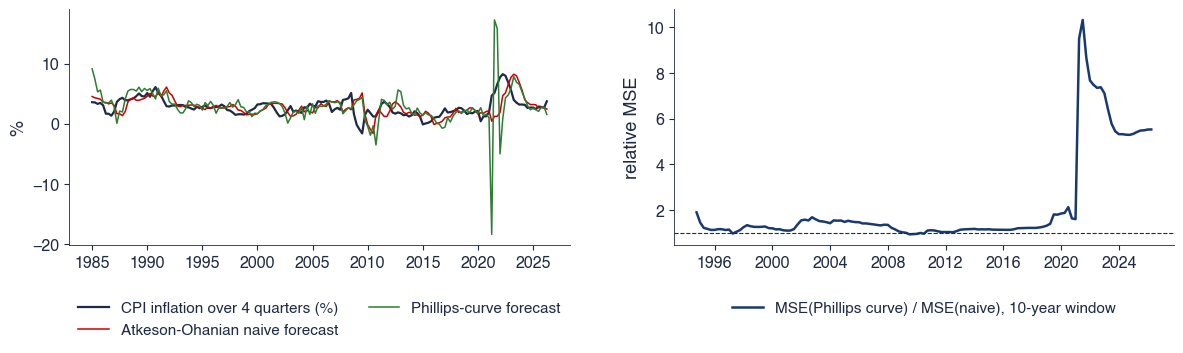

{'n': 166, 'first': '1985-01-01', 'last': '2026-04-01', 'rmse_naive': 1.6935099731031584, 'rmse_pc': 2.966350120396866, 'dm': {'T': 166, 'dbar': 5.931257007778644, 'dm': 1.18504038451663, 'p_dm': 0.23600147999395904, 'hln': 1.160049101881134, 'p_hln': 0.24770461754648185, 'kernel': 'rect'}, 'rel_min': 0.9329501232450591, 'rel_max': 10.326246709211368, 'rel_min_d': '2009-07-01', 'rel_max_d': '2021-07-01', 'ratio': 1.7515988494365802, 'gw': {'T': 162, 'q': 2, 'stat': 2.0712578965094397, 'p': 0.35500303215740975}, 'gw_u': {'T': 166, 'q': 2, 'stat': 2.2638001620770876, 'p': 0.32242004981252065}, 'enc_naive': {'T': 166, 'dbar': 0.2659901715129499, 'dm': 0.5698743907318107, 'p_dm': 0.5687628954559514, 'hln': 0.5578563260720828, 'p_hln': 0.577698596612336, 'kernel': 'bartlett', 'p_one': 0.288849298306168}, 'enc_pc': {'T': 166, 'dbar': 6.197247179291594, 'dm': 1.216981866287994, 'p_dm': 0.2236111153518795, 'hln': 1.19131697066076, 'p_hln': 0.2352400142536599, 'kernel': 'rect', 'p_one': 0.11762

In [11]:
def ao_forecasts(win=AO_WIN, L=AO_LAGS, first=AO_EVAL):
    """Atkeson and Ohanian (2001): the forecast of inflation over the next four quarters equals inflation over the last
    four quarters; against the Phillips-curve equation of Stock and Watson (1999),
    pi4_{t+4} - pi4_t = a + b(L) u_t + c(L) d(pi_t) + e, with L lags, estimated on a rolling window of `win` quarters."""
    p, _ = us_cpi_quarterly()
    lp = np.log(p)
    pi = 400 * lp.diff()                         # quarterly inflation, annualised
    pi4 = 100 * (lp - lp.shift(4))               # inflation over four quarters
    u = read_fred('UNRATE').resample('QS').mean().reindex(p.index)
    df = pd.DataFrame({'pi4': pi4, 'dpi': pi.diff(), 'u': u})
    df['target'] = df['pi4'].shift(-4)
    for k in range(L):
        df[f'u{k}'] = df['u'].shift(k)
        df[f'dpi{k}'] = df['dpi'].shift(k)
    regs = [f'u{k}' for k in range(L)] + [f'dpi{k}' for k in range(L)]
    rows = []
    idx = df.index
    for i, t in enumerate(idx):
        tgt = t + pd.DateOffset(months=12)
        if tgt < pd.Timestamp(first) or np.isnan(df['target'].iloc[i]):
            continue
        tr = df.iloc[max(0, i - 4 - win + 1):i - 4 + 1].dropna(subset=regs + ['target', 'pi4'])   # targets known at t
        X = np.column_stack([np.ones(len(tr))] + [tr[c] for c in regs])
        b = np.linalg.lstsq(X, (tr['target'] - tr['pi4']).values, rcond=None)[0]
        x = np.r_[1.0, df[regs].iloc[i].values]
        rows.append({'origin': t, 'target_q': tgt, 'y': df['target'].iloc[i], 'naive': df['pi4'].iloc[i],
                     'pc': df['pi4'].iloc[i] + x @ b, 'u': df['u'].iloc[i]})
    return pd.DataFrame(rows).set_index('target_q')


def fig_ao(save_it=True):
    """Atkeson-Ohanian on US CPI inflation: rolling relative MSE and the tests (DM-HLN, GW, encompassing)."""
    F = ao_forecasts()
    e_n, e_p = F['y'] - F['naive'], F['y'] - F['pc']
    d = (e_p ** 2 - e_n ** 2)
    rel = (e_p ** 2).rolling(40).mean() / (e_n ** 2).rolling(40).mean()
    fig, axs = plt.subplots(1, 2, figsize=(12, 3.8))
    ax = axs[0]
    ax.plot(F.index, F['y'], color=st.DarkText, lw=1.6, label='CPI inflation over 4 quarters (%)')
    ax.plot(F.index, F['naive'], color=st.IDAred, lw=1.1, label='Atkeson-Ohanian naive forecast')
    ax.plot(F.index, F['pc'], color=st.Forest, lw=1.1, label='Phillips-curve forecast')
    ax.set_ylabel('%')
    st.legend_outside_bottom(ax, ncol=2, y=-0.18)
    ax = axs[1]
    ax.plot(rel.index, rel, color=st.MainBlue, lw=1.8, label='MSE(Phillips curve) / MSE(naive), 10-year window')
    ax.axhline(1, color=st.DarkText, lw=0.8, ls='--')
    ax.set_ylabel('relative MSE')
    st.legend_outside_bottom(ax, ncol=1, y=-0.18)
    plt.tight_layout()
    save('ats_ch1_ao', save_it)
    out = {'n': int(len(F)), 'first': str(F.index[0].date()), 'last': str(F.index[-1].date()),
           'rmse_naive': float(np.sqrt(np.mean(e_n ** 2))), 'rmse_pc': float(np.sqrt(np.mean(e_p ** 2))),
           'dm': dm_test(d, 4), 'rel_min': float(rel.min()), 'rel_max': float(rel.max()),
           'rel_min_d': str(rel.idxmin().date()), 'rel_max_d': str(rel.idxmax().date())}
    out['ratio'] = out['rmse_pc'] / out['rmse_naive']
    dl = d.shift(4).values
    out['gw'] = gw_test(d.values, [dl], 4)
    out['gw_u'] = gw_test(d.values, [F['u'].values], 4)
    out['enc_naive'] = encompassing_test(F['y'].values, F['naive'].values, F['pc'].values, 4)
    out['enc_pc'] = encompassing_test(F['y'].values, F['pc'].values, F['naive'].values, 4)
    for a, b in [('1985', '2007'), ('2008', '2019'), ('2020', '2026')]:
        s = slice(a, b)
        out[f'ratio_{a}'] = float(np.sqrt(np.mean(e_p[s] ** 2) / np.mean(e_n[s] ** 2)))
    return out


print(fig_ao(save_it=False))

## 6. EUR/RON against the random walk: Clark–West and SPA

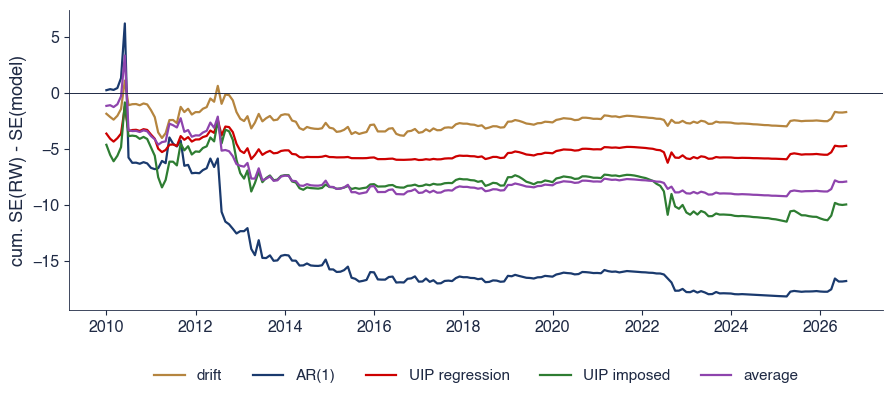

{'n': 200, 'first': '2010-01-01', 'last': '2026-08-01', 'rmse_rw': 0.861478911214093, 'drift': {'rel_rmse': 1.0057728319082402, 'dm': {'T': 200, 'dbar': 0.008593299680366371, 'dm': 0.2747381319206794, 'p_dm': 0.7835174329890997, 'hln': 0.27405042588109274, 'p_hln': 0.7843301256628408, 'kernel': 'rect'}, 'cw': {'T': 200, 'cw': 1.0595475073994507, 'p': 0.14467525267426168}}, 'UIP imposed': {'rel_rmse': 1.0329810219325435, 'dm': {'T': 200, 'dbar': 0.04976072895580818, 'dm': 0.9972295781597915, 'p_dm': 0.3186530870030344, 'hln': 0.9947333800566722, 'p_hln': 0.3210739524059992, 'kernel': 'rect'}}, 'momentum': {'rel_rmse': 1.183472730300667, 'dm': {'T': 200, 'dbar': 0.29730937035642435, 'dm': 2.620504598617225, 'p_dm': 0.008779974595377247, 'hln': 2.613945127506917, 'p_hln': 0.009634724187305032, 'kernel': 'rect'}}, 'AR(1)': {'rel_rmse': 1.0549993755866098, 'dm': {'T': 200, 'dbar': 0.08388006419654309, 'dm': 1.1301460141235056, 'p_dm': 0.25841470342341266, 'hln': 1.1273171085249485, 'p_hln':

In [12]:
def eurron_data():
    """Monthly EUR/RON (BNR reference rate, last day of the month), 100 x log change, and the 3-month rate
    differential Romania minus euro area (Eurostat), in % per month."""
    s = read_reference_rate('EUR', start=FX_START).resample('MS').last()
    ds = 100 * np.log(s).diff()
    i_ro = read_eurostat(*RATE_RO)
    i_ea = read_eurostat(*RATE_EA)
    x = ((i_ro - i_ea) / 12).reindex(ds.index)
    return pd.DataFrame({'ds': ds, 'x': x}).dropna()


def eurron_forecasts(first=FX_EVAL):
    """One-month-ahead forecasts of the EUR/RON log change made recursively (expanding window): random walk (0),
    drift (mean), AR(1..4), UIP regression ds_{t+1} = a + b x_t, UIP imposed (ds = x_t, nothing estimated), momentum
    (mean of the last 3 changes) and the equal-weight average of the estimated models."""
    df = eurron_data()
    ds, x = df['ds'].values, df['x'].values
    rows = []
    for i in range(len(df) - 1):
        t1 = df.index[i + 1]
        if t1 < pd.Timestamp(first):
            continue
        r = {'date': t1, 'y': ds[i + 1], 'RW': 0.0, 'drift': ds[:i + 1].mean(), 'UIP imposed': x[i],
             'momentum': ds[i - 2:i + 1].mean()}
        for p in range(1, 5):
            Y = ds[p:i + 1]
            X = np.column_stack([np.ones(len(Y))] + [ds[p - k:i + 1 - k] for k in range(1, p + 1)])
            b = np.linalg.lstsq(X, Y, rcond=None)[0]
            r[f'AR({p})'] = float(np.r_[1.0, ds[i::-1][:p]] @ b)
        Y, X = ds[1:i + 1], np.column_stack([np.ones(i), x[:i]])
        b = np.linalg.lstsq(X, Y, rcond=None)[0]
        r['UIP regression'] = float(b[0] + b[1] * x[i])
        rows.append(r)
    F = pd.DataFrame(rows).set_index('date')
    F['average'] = F[['drift', 'AR(1)', 'AR(2)', 'UIP regression']].mean(axis=1)
    return F


def fig_eurron(save_it=True):
    """EUR/RON against the random walk: cumulative SSE differences; Clark-West, naive DM and Hansen's SPA."""
    from arch.bootstrap import SPA
    F = eurron_forecasts()
    y = F['y']
    models = [c for c in F.columns if c not in ('y', 'RW')]
    fig, ax = plt.subplots(figsize=(10.5, 3.9))
    cols = {'drift': st.Amber, 'AR(1)': st.MainBlue, 'UIP regression': st.IDAred, 'UIP imposed': st.Forest,
            'average': st.Purple}
    for m, c in cols.items():
        ax.plot(F.index, np.cumsum((y - F['RW']) ** 2 - (y - F[m]) ** 2), color=c, lw=1.6, label=m)
    ax.axhline(0, color=st.DarkText, lw=0.7)
    ax.set_ylabel('cum. SE(RW) - SE(model)')
    st.legend_outside_bottom(ax, ncol=5, y=-0.15)
    save('ats_ch1_eurron', save_it)
    out = {'n': int(len(F)), 'first': str(F.index[0].date()), 'last': str(F.index[-1].date()),
           'rmse_rw': float(np.sqrt(np.mean(y ** 2)))}
    for m in models:
        e = y - F[m]
        out[m] = {'rel_rmse': float(np.sqrt(np.mean(e ** 2)) / out['rmse_rw']),
                  'dm': dm_test(e ** 2 - y ** 2, 1)}
        if m not in ('UIP imposed', 'momentum', 'average'):
            out[m]['cw'] = cw_test(y.values, F['RW'].values, F[m].values, 1)
    L = pd.DataFrame({m: (y - F[m]) ** 2 for m in models})
    spa = SPA((y ** 2).values, L.values, reps=BOOT_B, block_size=6, bootstrap='stationary', seed=SEED)
    spa.compute()
    out['spa'] = {'lower': float(spa.pvalues['lower']), 'consistent': float(spa.pvalues['consistent']),
                  'upper': float(spa.pvalues['upper']), 'k': len(models)}
    return out


print(fig_eurron(save_it=False))

## 7. Romanian electricity load: pinball loss and the Model Confidence Set

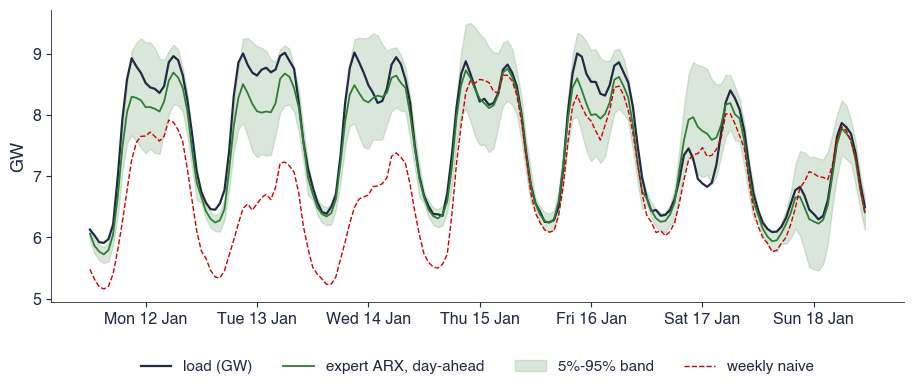

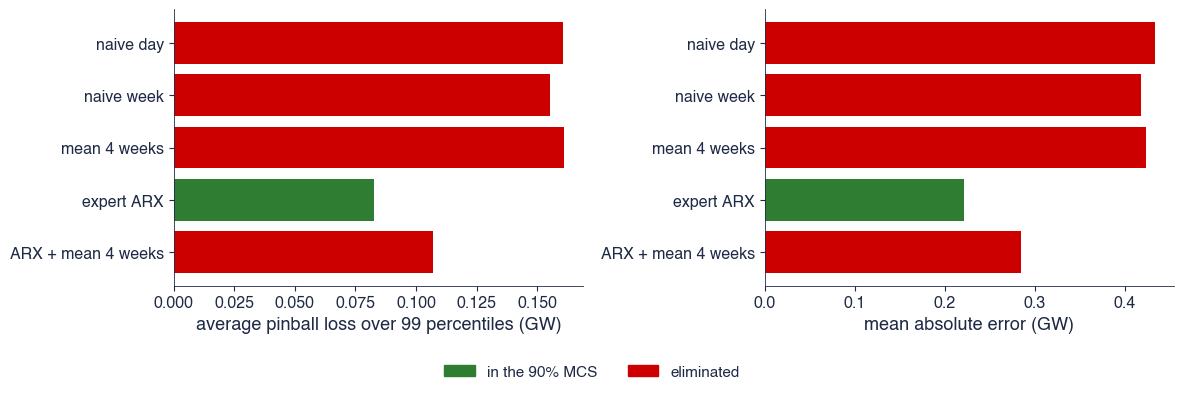

{'n_days': 638, 'first': '2025-01-01', 'last': '2026-09-30', 'mean_load': 5.980999583659875, 'max_load': 9.20775, 'min_load': 2.54675, 'pin': {'naive day': 0.16078637988746694, 'naive week': 0.1551738325157416, 'mean 4 weeks': 0.16090671621832262, 'expert ARX': 0.08267829776927882, 'ARX + mean 4 weeks': 0.10708512729939469}, 'mae': {'naive day': 0.4328918070794148, 'naive week': 0.4174767208725183, 'mean 4 weeks': 0.42300772515020896, 'expert ARX': 0.22119654323359442, 'ARX + mean 4 weeks': 0.2845466302997987}, 'mcs_pin': {'p': {'naive day': 0.0, 'naive week': 0.0, 'mean 4 weeks': 0.0, 'expert ARX': 1.0, 'ARX + mean 4 weeks': 0.0}, 'set': ['expert ARX']}, 'mcs_mae': {'p': {'naive day': 0.0, 'naive week': 0.0, 'mean 4 weeks': 0.0, 'expert ARX': 1.0, 'ARX + mean 4 weeks': 0.0}, 'set': ['expert ARX']}, 'cov90': {'naive day': 0.892110762800418, 'naive week': 0.8757183908045977, 'mean 4 weeks': 0.8866901776384535, 'expert ARX': 0.8819226750261233, 'ARX + mean 4 weeks': 0.8828369905956113}, 

In [13]:
def load_forecasts(win=LOAD_WIN, res_win=LOAD_RES, first=LOAD_EVAL):
    """Day-ahead forecasts of the 24 hourly loads of day d + 1 with data up to day d:
    naive (day d), weekly naive (day d - 6), mean of the last four same weekdays, the expert ARX model of
    Ziel and Weron (2018) for each hour (y_{d,h}, y_{d-1,h}, y_{d-6,h}, min_d, max_d, y_{d,24}, Monday, Saturday,
    Sunday; rolling window `win` days) and the average of ARX and the four-week mean. Quantiles: point forecast plus
    empirical quantiles of the model's last `res_win` errors at the same hour."""
    Y = ro_load_hourly() / 1000.0                              # GW
    days = Y.index
    A = Y.values
    nD = len(days)
    dow = np.array([d.dayofweek for d in days])
    start = int(np.searchsorted(days, pd.Timestamp(first)))
    names = ['naive day', 'naive week', 'mean 4 weeks', 'expert ARX', 'ARX + mean 4 weeks']
    P = {n: np.full((nD, 24), np.nan) for n in names}
    for d1 in range(28, nD):
        d = d1 - 1
        P['naive day'][d1] = A[d]
        P['naive week'][d1] = A[d1 - 7]
        P['mean 4 weeks'][d1] = A[[d1 - 7, d1 - 14, d1 - 21, d1 - 28]].mean(axis=0)
    mins, maxs, last = A.min(axis=1), A.max(axis=1), A[:, 23]
    for d1 in range(max(start - res_win - 1, win + 8), nD):
        rows = np.arange(d1 - win, d1)                       # targets in the window
        rows = rows[rows >= 8]
        for h in range(24):
            X = np.column_stack([np.ones(len(rows)), A[rows - 1, h], A[rows - 2, h], A[rows - 7, h], mins[rows - 1],
                                 maxs[rows - 1], last[rows - 1], dow[rows] == 0, dow[rows] == 5, dow[rows] == 6])
            b = np.linalg.lstsq(X, A[rows, h], rcond=None)[0]
            x = np.r_[1.0, A[d1 - 1, h], A[d1 - 2, h], A[d1 - 7, h], mins[d1 - 1], maxs[d1 - 1], last[d1 - 1],
                      dow[d1] == 0, dow[d1] == 5, dow[d1] == 6]
            P['expert ARX'][d1, h] = x @ b
    P['ARX + mean 4 weeks'] = 0.5 * (P['expert ARX'] + P['mean 4 weeks'])
    Q = {}
    for n in names:
        E = A - P[n]
        Q[n] = np.full((nD, 24, len(TAUS)), np.nan)
        for d1 in range(start, nD):
            R = E[d1 - res_win:d1]
            Q[n][d1] = P[n][d1][:, None] + np.nanquantile(R, TAUS, axis=0).T
    return days[start:], A[start:], {n: P[n][start:] for n in names}, {n: Q[n][start:] for n in names}


def fig_load(save_it=True):
    """Romanian load: one week of forecasts with 5-95% bands; daily pinball and MAE; Model Confidence Set."""
    days, A, P, Q = load_forecasts()
    names = list(P)
    pin = {}
    mae = {}
    for n in names:
        pl = pinball(A[:, :, None], Q[n], TAUS[None, None, :]).mean(axis=2)     # days x 24
        pin[n] = pl.mean(axis=1)
        mae[n] = np.abs(A - P[n]).mean(axis=1)
    Lp, Lm = pd.DataFrame(pin, index=days), pd.DataFrame(mae, index=days)
    M = mcs(Lp)
    Mm = mcs(Lm)
    # chart 1: a week in January 2026
    wk = slice(int(np.searchsorted(days, pd.Timestamp('2026-01-12'))), int(np.searchsorted(days, pd.Timestamp('2026-01-19'))))
    t = np.arange(7 * 24)
    fig, ax = plt.subplots(figsize=(11, 3.8))
    ax.plot(t, A[wk].ravel(), color=st.DarkText, lw=1.6, label='load (GW)')
    ax.plot(t, P['expert ARX'][wk].ravel(), color=st.Forest, lw=1.3, label='expert ARX, day-ahead')
    q05, q95 = Q['expert ARX'][wk][:, :, 4].ravel(), Q['expert ARX'][wk][:, :, 94].ravel()
    ax.fill_between(t, q05, q95, color=st.Forest, alpha=0.18, label='5%-95% band')
    ax.plot(t, P['naive week'][wk].ravel(), color=st.IDAred, lw=1.0, ls='--', label='weekly naive')
    ax.set_xticks(np.arange(0, 7 * 24, 24) + 12)
    ax.set_xticklabels([d.strftime('%a %d %b') for d in days[wk]])
    ax.set_ylabel('GW')
    st.legend_outside_bottom(ax, ncol=4, y=-0.15)
    save('ats_ch1_load_week', save_it)
    # chart 2: average pinball and MAE, MCS members
    fig, axs = plt.subplots(1, 2, figsize=(12, 3.6))
    for ax, L, MM, lab in [(axs[0], Lp, M, 'average pinball loss over 99 percentiles (GW)'),
                           (axs[1], Lm, Mm, 'mean absolute error (GW)')]:
        v = L.mean()
        cs = [st.Forest if n in MM['set'] else st.IDAred for n in names]
        ax.barh(range(len(names)), v.values, color=cs)
        ax.set_yticks(range(len(names)))
        ax.set_yticklabels(names)
        ax.invert_yaxis()
        ax.set_xlabel(lab)
    from matplotlib.patches import Patch
    fig.legend([Patch(color=st.Forest), Patch(color=st.IDAred)], ['in the 90% MCS', 'eliminated'], loc='upper center',
               bbox_to_anchor=(0.5, 0.0), ncol=2, frameon=False)
    plt.tight_layout()
    save('ats_ch1_load_mcs', save_it)
    out = {'n_days': int(len(days)), 'first': str(days[0].date()), 'last': str(days[-1].date()),
           'mean_load': float(A.mean()), 'max_load': float(A.max()), 'min_load': float(A.min()),
           'pin': {n: float(Lp[n].mean()) for n in names}, 'mae': {n: float(Lm[n].mean()) for n in names},
           'mcs_pin': M, 'mcs_mae': Mm}
    for n in names:
        q = Q[n]
        out.setdefault('cov90', {})[n] = float(np.mean((A >= q[:, :, 4]) & (A <= q[:, :, 94])))
    out['dm_arx_comb'] = dm_test(Lp['expert ARX'] - Lp['ARX + mean 4 weeks'], 1)
    out['dm_arx_week'] = dm_test(Lp['expert ARX'] - Lp['naive week'], 1)
    worst = Lp['expert ARX'].sort_values(ascending=False).head(5)
    out['worst_days'] = [str(d.date()) for d in worst.index]
    return out


print(fig_load(save_it=False))

## 8. Forecast combination: the puzzle and the US SPF

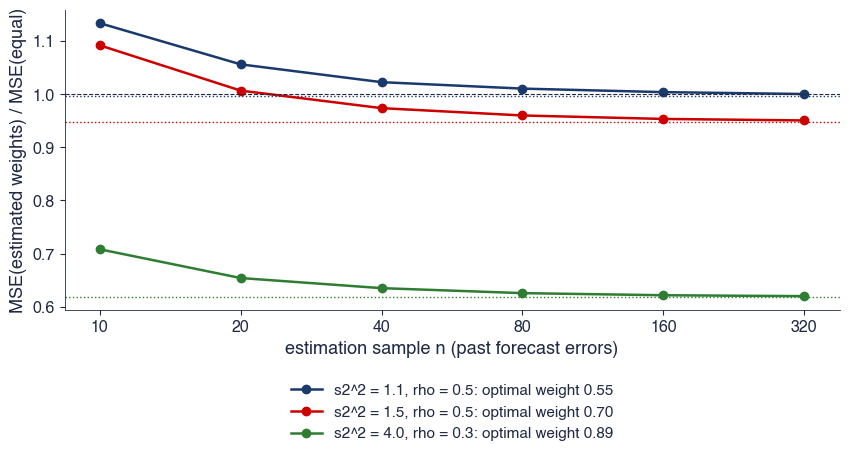

{'1.1_0.5': {'w_opt': 0.5475650883409389, 'pop': 0.9969788519637461, 'ratios': {'10': 1.1333568421932614, '20': 1.055886365736421, '40': 1.0223859156736803, '80': 1.0102884891781907, '160': 1.0036375082073192, '320': 1.0001072049505533}}, '1.5_0.5': {'w_opt': 0.696039203757452, 'pop': 0.9473684210526315, 'ratios': {'10': 1.091675592519836, '20': 1.006531763594103, '40': 0.9735254229147873, '80': 0.9597673554916104, '160': 0.9532409818064638, '320': 0.9504250560508228}}, '4.0_0.3': {'w_opt': 0.8947368421052632, 'pop': 0.6179966044142614, 'ratios': {'10': 0.7081496358761113, '20': 0.6541001912408565, '40': 0.6350639932921966, '80': 0.6257148730428536, '160': 0.621732958860328, '320': 0.6200235242570289}}, 'reps': 2000}


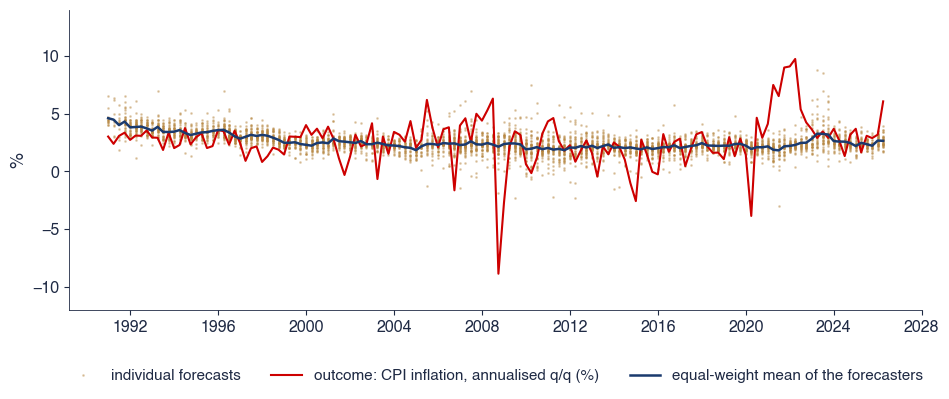

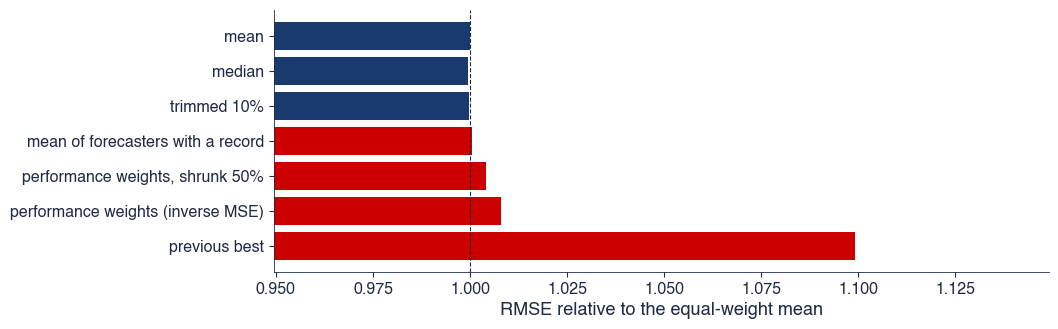

{'mean': 1.0, 'median': 0.9994214313658648, 'trimmed 10%': 0.999767818409088, 'mean of eligible': 1.0005298172501953, 'shrink 0.50': 1.0040698356430577, 'shrink 1.00': 1.0080392039434551, 'previous best': 1.0990791964695172}


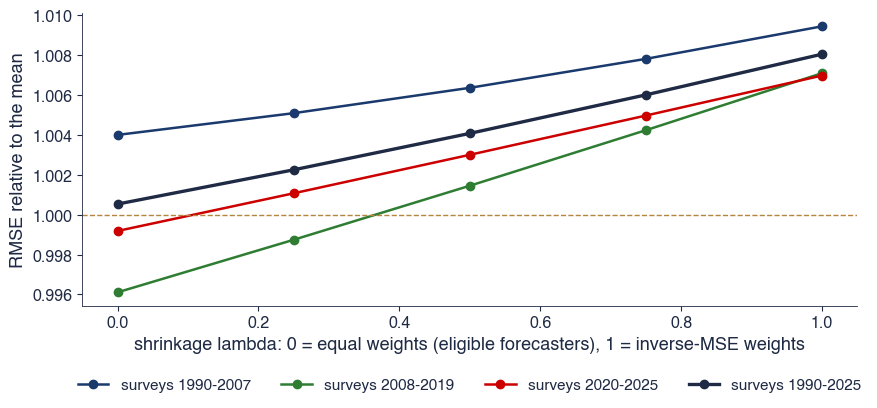

{'1990_2007': {'0.00': 1.0039941826492254, '0.25': 1.0050830177167769, '0.50': 1.0063531102573227, '0.75': 1.007803774977679, '1.00': 1.009434233373666, 'n': 72}, '2008_2019': {'0.00': 0.9961090343860061, '0.25': 0.9987409847593014, '0.50': 1.0014483409620945, '0.75': 1.0042304931233068, '1.00': 1.007086821354953, 'n': 48}, '2020_2025': {'0.00': 0.9991816356295734, '0.25': 1.0010699544137207, '0.50': 1.0029974301052154, '0.75': 1.0049638374004917, '1.00': 1.0069689482228614, 'n': 22}, '1990_2025': {'0.00': 1.0005298172501953, '0.25': 1.0022458604318873, '0.50': 1.0040698356430577, '0.75': 1.006001155810955, '1.00': 1.0080392039434551, 'n': 142}, 'dm_0.50': {'T': 142, 'dbar': 0.03892248910385598, 'dm': 1.2033294445577045, 'p_dm': 0.22884885909041242, 'hln': 1.1651880611775307, 'p_hln': 0.24591030172750802, 'kernel': 'rect'}, 'dm_1.00': {'T': 142, 'dbar': 0.07703642443349835, 'dm': 1.7567595374197458, 'p_dm': 0.078958804601416, 'hln': 1.7010763333507788, 'p_hln': 0.09113294511943666, 'ke

In [14]:
def fig_puzzle(save_it=True, reps=4000):
    """The combination puzzle (Smith and Wallis 2009): two unbiased forecasts with error variances s1^2 = 1, s2^2 and
    correlation rho. Weights estimated on n past errors (Bates-Granger) against equal weights, evaluated out of sample:
    MSE(estimated weights) / MSE(equal weights) as a function of n, and the population ratio MSE(optimal) / MSE(equal)."""
    rng = np.random.default_rng(SEED)
    ns = [10, 20, 40, 80, 160, 320]
    cases = [(1.1, 0.5, st.MainBlue), (1.5, 0.5, st.IDAred), (4.0, 0.3, st.Forest)]
    fig, ax = plt.subplots(figsize=(10, 3.9))
    out = {}
    for s2, rho, c in cases:
        S = np.array([[1, rho * np.sqrt(s2)], [rho * np.sqrt(s2), s2]])
        w_opt = (s2 - S[0, 1]) / (1 + s2 - 2 * S[0, 1])
        mse = lambda w: w ** 2 + (1 - w) ** 2 * s2 + 2 * w * (1 - w) * S[0, 1]
        pop = mse(w_opt) / mse(0.5)
        ratios = []
        for n in ns:
            E = rng.multivariate_normal([0, 0], S, size=(reps, n))
            v1, v2 = E[:, :, 0].var(axis=1), E[:, :, 1].var(axis=1)
            c12 = (E[:, :, 0] * E[:, :, 1]).mean(axis=1) - E[:, :, 0].mean(axis=1) * E[:, :, 1].mean(axis=1)
            w = (v2 - c12) / (v1 + v2 - 2 * c12)
            ratios.append(float(np.mean(mse(w)) / mse(0.5)))
        lab = f's2^2 = {s2}, rho = {rho}: optimal weight {w_opt:.2f}'
        ax.plot(ns, ratios, 'o-', color=c, lw=1.8, label=lab)
        ax.axhline(pop, color=c, lw=1.0, ls=':')
        out[f'{s2}_{rho}'] = {'w_opt': float(w_opt), 'pop': float(pop), 'ratios': dict(zip(map(str, ns), ratios))}
    ax.axhline(1, color=st.DarkText, lw=0.8, ls='--')
    ax.set_xscale('log', base=2)
    ax.set_xticks(ns)
    ax.set_xticklabels([str(n) for n in ns])
    ax.set_xlabel('estimation sample n (past forecast errors)')
    ax.set_ylabel('MSE(estimated weights) / MSE(equal)')
    st.legend_outside_bottom(ax, ncol=1, y=-0.2)
    save('ats_ch1_puzzle', save_it)
    out['reps'] = reps
    return out


def fig_spf(save_it=True):
    """US SPF, CPI inflation four quarters ahead: individual forecasts, the mean and the outcome; combination schemes."""
    W, y = spf_panel()
    C = combine_spf(W, y)
    C = C[(C.index.year >= SPF_EVAL[0]) & (C.index.year <= SPF_EVAL[1])].dropna(subset=['shrink 1.00'])
    fig, ax = plt.subplots(figsize=(11, 3.9))
    Ws = W.loc[C.index]
    tq = (C.index + (SPF_H - 2)).to_timestamp()
    xx = np.repeat(tq.values, Ws.shape[1])
    vv = Ws.values.ravel()
    ok = ~np.isnan(vv)
    ax.plot(xx[ok], vv[ok], '.', ms=2, color=st.Amber, alpha=0.35, label='individual forecasts')
    ax.plot(tq, C['y'], color=st.IDAred, lw=1.5, label='outcome: CPI inflation, annualised q/q (%)')
    ax.plot(tq, C['mean'], color=st.MainBlue, lw=1.8, label='equal-weight mean of the forecasters')
    ax.set_ylabel('%')
    ax.set_ylim(-12, 14)
    st.legend_outside_bottom(ax, ncol=3, y=-0.15)
    save('ats_ch1_spf', save_it)
    schemes = ['mean', 'median', 'trimmed 10%', 'mean of eligible', 'shrink 0.50', 'shrink 1.00', 'previous best']
    rm = {s: float(np.sqrt(np.mean((C['y'] - C[s]) ** 2))) for s in schemes}
    fig, ax = plt.subplots(figsize=(10, 3.4))
    rel = [rm[s] / rm['mean'] for s in schemes]
    labs = {'shrink 0.50': 'performance weights, shrunk 50%', 'shrink 1.00': 'performance weights (inverse MSE)',
            'mean of eligible': 'mean of forecasters with a record'}
    ax.barh(range(len(schemes)), rel, color=[st.MainBlue if r <= 1.0 else st.IDAred for r in rel])
    ax.axvline(1, color=st.DarkText, lw=0.8, ls='--')
    ax.set_yticks(range(len(schemes)))
    ax.set_yticklabels([labs.get(s, s) for s in schemes])
    ax.invert_yaxis()
    ax.set_xlim(min(rel) - 0.05, max(rel) + 0.05)
    ax.set_xlabel('RMSE relative to the equal-weight mean')
    save('ats_ch1_spf_schemes', save_it)
    out = {'n': int(len(C)), 'first': str(C.index[0]), 'last': str(C.index[-1]), 'n_forecasters': int(W.loc[C.index].notna().any().sum()),
           'avg_panel': float(C['n'].mean()), 'avg_ok': float(C['n_ok'].mean()), 'rmse': rm,
           'rel': dict(zip(schemes, rel))}
    for s in schemes[1:]:
        out[f'dm_{s}'] = dm_test((C['y'] - C[s]) ** 2 - (C['y'] - C['mean']) ** 2, SPF_H - 1)
    out['mz'] = mz_test(C['y'].values, C['mean'].values, SPF_H - 1)
    # dispersion of individual RMSEs among forecasters with at least 20 evaluated forecasts
    E = (W.loc[C.index].sub(C['y'], axis=0)) ** 2
    cnt = E.notna().sum()
    ind = np.sqrt(E.loc[:, cnt >= 20].mean())
    out['ind_n'] = int(len(ind))
    out['ind_share_beat'] = float(np.mean(ind < rm['mean']))
    out['ind_best'] = float(ind.min())
    out['ind_median'] = float(ind.median())
    for a, b in [(1990, 2007), (2008, 2019), (2020, 2025)]:
        m = (C.index.year >= a) & (C.index.year <= b)
        out[f'sub_{a}'] = {s: float(np.sqrt(np.mean((C['y'][m] - C[s][m]) ** 2)) / np.sqrt(np.mean((C['y'][m] - C['mean'][m]) ** 2)))
                           for s in schemes}
    return out


def fig_ai_case(save_it=True):
    """AI mini-case: does the ranking of SPF combination schemes survive sub-periods and the shrinkage factor?"""
    W, y = spf_panel()
    C = combine_spf(W, y)
    C = C[(C.index.year >= SPF_EVAL[0]) & (C.index.year <= SPF_EVAL[1])].dropna(subset=['shrink 1.00'])
    lam = [0.0, 0.25, 0.5, 0.75, 1.0]
    periods = [(1990, 2007, st.MainBlue), (2008, 2019, st.Forest), (2020, 2025, st.IDAred), (1990, 2025, st.DarkText)]
    fig, ax = plt.subplots(figsize=(10, 3.8))
    out = {}
    for a, b, c in periods:
        m = (C.index.year >= a) & (C.index.year <= b)
        base = np.sqrt(np.mean((C['y'][m] - C['mean'][m]) ** 2))
        v = [float(np.sqrt(np.mean((C['y'][m] - C[f'shrink {l:.2f}'][m]) ** 2)) / base) for l in lam]
        ax.plot(lam, v, 'o-', color=c, lw=1.8 if b - a < 30 else 2.4, label=f'surveys {a}-{b}')
        out[f'{a}_{b}'] = dict(zip([f'{l:.2f}' for l in lam], v))
        out[f'{a}_{b}']['n'] = int(m.sum())
    ax.axhline(1, color=st.Amber, lw=1, ls='--')
    ax.set_xlabel('shrinkage lambda: 0 = equal weights (eligible forecasters), 1 = inverse-MSE weights')
    ax.set_ylabel('RMSE relative to the mean')
    st.legend_outside_bottom(ax, ncol=4, y=-0.2)
    save('ats_ch1_ai_case', save_it)
    for l in (0.5, 1.0):
        out[f'dm_{l:.2f}'] = dm_test((C['y'] - C[f'shrink {l:.2f}']) ** 2 - (C['y'] - C['mean']) ** 2, SPF_H - 1)
    return out


print(fig_puzzle(save_it=False, reps=2000))
print(fig_spf(save_it=False)['rel'])
print(fig_ai_case(save_it=False))

## 9. Real-time data: US GDP vintages

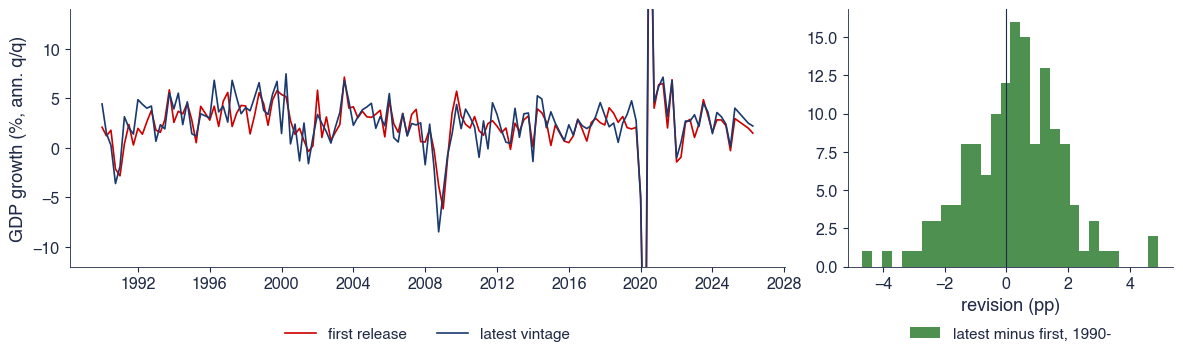

{'n': 143, 'mean_rev': 0.23269580419580416, 'sd_rev': 1.5406472172468424, 'mad_rev': 1.2081881118881117, 'corr': 0.9394131423439148, 'n_spf': 143, 'rmse_first': 1.9484448590112586, 'rmse_latest': 2.3637573763690973, 'mz_first': {'a': -0.17462933448918144, 'b': 1.1459370790717305, 'se_a': 0.19629507292085488, 'se_b': 0.09641303116218039, 'wald': 2.3407576781802146, 'p': 0.31024938440482963, 'r2': 0.8191537139845682}, 'mz_latest': {'a': 0.2086392083368778, 'b': 1.0779048019046629, 'se_a': 0.2891598452904202, 'se_b': 0.12707502448720986, 'wald': 3.5857135660149564, 'p': 0.16648388134153172, 'r2': 0.7241260248384771}, 'last_q': '2026-04-01', 'big': [['2020Q2', 4.9278999999999975], ['2008Q4', -4.6681], ['1997Q2', 4.6640999999999995]]}


In [15]:
def fig_realtime(save_it=True):
    """US real GDP growth: first release against the latest vintage (RTDSM), the revisions, and the SPF
    current-quarter nowcast (mean of RGDP2/RGDP1) evaluated against each of them."""
    R = realtime_gdp().dropna(subset=['first', 'latest'])
    rev = R['latest'] - R['first']
    fig, axs = plt.subplots(1, 2, figsize=(12, 3.8), gridspec_kw={'width_ratios': [2.2, 1]})
    ax = axs[0]
    s = R.loc['1990':]
    ax.plot(s.index, s['first'], color=st.IDAred, lw=1.2, label='first release')
    ax.plot(s.index, s['latest'], color=st.MainBlue, lw=1.2, label='latest vintage')
    ax.set_ylabel('GDP growth (%, ann. q/q)')
    ax.set_ylim(-12, 14)
    st.legend_outside_bottom(ax, ncol=2, y=-0.18)
    ax = axs[1]
    ax.hist(rev.loc['1990':].clip(-6, 6), bins=30, color=st.Forest, alpha=0.85, label='latest minus first, 1990-')
    ax.axvline(0, color=st.DarkText, lw=0.8)
    ax.set_xlabel('revision (pp)')
    st.legend_outside_bottom(ax, ncol=1, y=-0.18)
    plt.tight_layout()
    save('ats_ch1_realtime', save_it)
    g = spf_sheet('RGDP')
    g['survey'] = pd.PeriodIndex.from_fields(year=g['YEAR'], quarter=g['QUARTER'], freq='Q')
    g['now'] = 100 * ((g['RGDP2'] / g['RGDP1']) ** 4 - 1)
    nc = g.groupby('survey')['now'].mean()
    Rq = R.copy()
    Rq.index = pd.PeriodIndex(Rq.index, freq='Q')
    J = pd.DataFrame({'f': nc}).join(Rq[['first', 'latest']], how='inner').loc['1990Q1':].dropna()
    out = {'n': int(len(rev.loc['1990':])), 'mean_rev': float(rev.loc['1990':].mean()), 'sd_rev': float(rev.loc['1990':].std()),
           'mad_rev': float(rev.loc['1990':].abs().mean()), 'corr': float(np.corrcoef(R.loc['1990':, 'first'], R.loc['1990':, 'latest'])[0, 1]),
           'n_spf': int(len(J)), 'rmse_first': float(np.sqrt(np.mean((J['first'] - J['f']) ** 2))),
           'rmse_latest': float(np.sqrt(np.mean((J['latest'] - J['f']) ** 2))),
           'mz_first': mz_test(J['first'].values, J['f'].values, 1), 'mz_latest': mz_test(J['latest'].values, J['f'].values, 1),
           'last_q': str(R.index[-1].date())}
    big = rev.loc['1990':].abs().sort_values(ascending=False).head(3)
    out['big'] = [[str(pd.Period(i, 'Q')), float(rev[i])] for i in big.index]
    return out


print(fig_realtime(save_it=False))

## Exercises

1. Re-run the Romanian inflation comparison with a 5-year rolling window and with a recursive window; which of the two is valid for the Giacomini–White test?
2. Add a threshold-weighted CRPS that focuses on the left tail of the S&P 500 forecasts and compare the rankings.
3. Add a Phillips curve with the output gap instead of unemployment to the Atkeson–Ohanian comparison.